# Deep Hedging - Testing & Ideas

### Ideas

- Transaction costs
- Deep hedging (batches with different models (Heston, G2++, GARCH, etc.))
- Other risk measure (for optimizing final pnl)
- Time dependant risk measure (risk managed paths pnl)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq #solve implied vol
from scipy.integrate import quad  #integrate

___
# Hedging Under Transaction Costs

### Black-Scholes with Transaction Costs

##### Utility based option pricing

Based on (VALERI I. ZAKAMOULINE, 2006)

Define the value function of the hedger with no option liability at time $t < T$ as
$$
J_0(t, x_t, y_t, S_t) = \text{max} \, \text{E}_t[U(x_T + y_T S_T)]
$$
where $S_t$ is the asset price, $x_t$ is the amount in the bank account, $y_t$ is the number of shares, and $U(z)$ is the hedger's utility function.

Now, the value function of the hedger with an option liability at time $t < T$ is
$$
J_w(t, x_t, y_t, S_t) = \text{max} \, \text{E}_t[U(x_T + y_T S_T - (S_T - K)^+)]
$$

Define the option price $P$ as the compensation between both value function such that:
$$
J_w(t, x_t + P, y_t, S_t) = J_0(t, x_t, y_t, S_t)
$$

Note that the solution to this problem is unique (one valid option price), which lead to the optimal hedging strategy. Unfortunately, this solution has no closed-form


Assume the hedger has the negative exponential utility function 
$$
U(z) = -e^{-\gamma z} \, , \, \, \, \, \gamma > 0
$$
where $\gamma$ is a measure of the hedger's (absolute) risk aversion

##### Asymptotic analysis : Delta's confidence bands

The idea is that instead of rebalancing the BS delta at each step, the hedger only rebalance when the delta falls outside the confidence band, and rebalance to the nearest boundary.

The delta's confidence band at time $t < T$ is define as:

$$
\text{Confidence Band} \ (\delta_t) = \frac{\partial V}{\partial S}(t) \pm H_t
$$
where the band half-width $H_t$ is

$$H_t = \left( \frac{3\kappa}{2\gamma} \cdot e^{r(T-t)} \cdot S_t^2 \cdot |\Gamma_{BS}(t)| \right)^{1/3}$$

where:

$\kappa$ = proportional transaction cost rate $\\\\$
$\gamma$ = absolute risk aversion parameter $\\\\$
$\Gamma_{BS}(t)$ = Black-Scholes gamma at time $t$: $H_t$ shrinks toward zero as $t \to T$ (gamma goes to zero away from the strike). Gamma is the second derivative of the option price with respect to $S$, or equivalently the rate of change of delta: $\Gamma = \frac{\partial \Delta}{\partial S} = \frac{\partial^2 C}{\partial S^2}$. Under Black-Scholes: $\Gamma_{BS}(S_t, t) = \frac{\phi(d_1)}{S_t \cdot \sigma \cdot \sqrt{T-t}}$, where $\phi(x)$ is the pdf of the standard normal rv.


In [ ]:
class BlackScholes:
    def __init__(self, S, K, r, sigma, T):
        self.S = S   # current asset price
        self.K = K   # strike
        self.r = r   # risk free rate
        self.sigma = sigma   #volatility
        self.T = T   # time to maturity

    def call_price(self):  
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)
        return self.S*norm.cdf(d1) - self.K*np.exp(-self.r*self.T)*norm.cdf(d2)
    def put_price(self):  # by put call parity
        return self.call_price() - self.S + self.K*np.exp(-self.r * self.T)
    
    def call_delta(self):  # first derivative with respect to price S 
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        return norm.cdf(d1)
    def put_delta(self):   # by derivative of put-call parity with respect to S
        return self.call_delta() - 1
    
    def gamma(self):
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        return norm.pdf(d1)/(self.S * self.sigma * np.sqrt(self.T))
    
    def delta_hedging(self, S_paths, Initial_portfolio=0,
                      transaction_cost=False, kappa=0, risk_aversion=1):
        # parameters
        ttm = np.linspace(self.T, 0,S_paths.shape[1])
        dt = self.T/(S_paths.shape[1] - 1)

        # call price value (initial value of the hedging portfolio)
        call_price_maturity = np.full(S_paths.shape[0], Initial_portfolio) * np.exp(self.r * self.T)

        # payoff (at maturity)
        payoff = np.maximum(S_paths[:,-1] - self.K, 0)

        # delta (not at maturity)
        S_grid = S_paths[:,:-1]
        T_grid = ttm[:-1]
        
        d1 = (np.log(S_grid/self.K) + (self.r + 0.5*(self.sigma**2))*T_grid)/(self.sigma * np.sqrt(T_grid))
        deltas = norm.cdf(d1)

        if transaction_cost:
            gamma = norm.pdf(d1) / (S_grid * self.sigma * np.sqrt(T_grid))
            H = ((1.5 * kappa / risk_aversion) * np.exp(-self.r * T_grid) * S_grid * (gamma**2))**(1/3)

            N_paths, N_steps = deltas.shape
            compound = np.exp(self.r * (self.T - ttm[1:]))

            # Sequential: track actual position under no-transaction band rule
            actual_deltas = np.zeros_like(deltas)
            delta_current = np.zeros(N_paths)       # start with no position

            for t in range(N_steps):
                lower = deltas[:, t] - H[:, t]
                upper = deltas[:, t] + H[:, t]

                new_delta = delta_current.copy()
                new_delta[delta_current < lower] = lower[delta_current < lower]   # buy to lower band
                new_delta[delta_current > upper] = upper[delta_current > upper]   # sell to upper band
                # else: stay — no trade

                actual_deltas[:, t] = new_delta
                delta_current = new_delta

            # PnL
            dS = S_paths[:, 1:] - S_paths[:, :-1] * np.exp(self.r * dt)
            hedging_pnl = np.sum(actual_deltas * dS * compound, axis=1)

            # Transaction costs: κ * |Δδ| * S_t, compounded to maturity
            prev_deltas = np.concatenate([np.zeros((N_paths, 1)), actual_deltas[:, :-1]], axis=1)
            tc = kappa * np.sum(np.abs(actual_deltas - prev_deltas) * S_grid * compound, axis=1)

            pnl = call_price_maturity + hedging_pnl - payoff - tc
            print(f"Black-Scholes (With Transaction Costs) | mean P&L={pnl.mean():.4f} | std={pnl.std():.4f} | mean TC={tc.mean():.4f}")
            return pnl, actual_deltas, tc

        else:  # pnl at each step t = 1 to T-1 
            compound = np.exp(self.r * (self.T - ttm[1:]))      # compounding each gain to maturity
            dS = S_paths[:, 1:] - S_paths[:, :-1] * np.exp(self.r * dt)         # discounted stock move
            hedging_pnl = np.sum(deltas * dS * compound, axis=1)

            # total pnl
            pnl = call_price_maturity + hedging_pnl - payoff
            print(f"Black-Scholes (No Transaction Costs) | mean P&L={pnl.mean():.4f} | std={pnl.std():.4f}")
            return pnl, deltas

In [157]:
def implied_vol(price, S, K, r, T, call=True):
    if call:
        def call_price(sigma):  
            d1 = (np.log(S/K) + (r + 0.5*(sigma**2))*T)/(sigma * np.sqrt(T))
            d2 = d1 - sigma*np.sqrt(T)
            return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        
        objective = lambda sigma: call_price(sigma) - price
        return brentq(objective, 1e-6, 10)

# Deep Hedging Agent

___
### Transaction Costs

In order to make the simulation of deep hedging more realistic, a transaction cost will be applied to each rebalancing decision the agent makes. The transaction cost is defined as followed:
$$
\text{TC}_t = S_t \ \kappa \ |\delta _t - \delta _{t-1}|
$$
where $\kappa$ is the constant transaction cost rate. (As reported in Bazzana and Collini (2020), transaction cost on the S&P 500 are around 0.047%).
Note that this is based on an assumption that transaction cost are equivalent for buying or selling the underlying asset.

___
### Deep Hedging Agent Set Up

Based on te work of Buehler and al. (2019), the deep hedging agent will be based on the following properties. 
- Feedforward Neural Network
- 2 hidden layers, 64 neurons per layer
- ReLU activation function
- Sigmoid output activation function
- 3 features, for each time $t < T$ 
    - Underlying asset price $S_t$ and the time to maturity $T-t$, which are time invariant (can be computed at $t_0$ given a simulated asset path)
    - Previous delta $\delta_{t-1}$, which helps the agent learn the transaction cost policy

Based on Buehler and al. (2019)

___
### Deep Hedging Agent

In [140]:
class DeepHedging(nn.Module):
    """
    Feed forward neural network with 2 hidden layers.
    - 3 inputs: log-moneyness, time to maturity, previous delta δ_{t-1}
    - Activation function: ReLU
    - Output activation function: Sigmoid (ensures delta in [0,1])
    """
    def __init__(self, K, r, T, kappa=0.0, num_features=3, hidden_size=64):
        super().__init__()
        self.K = K
        self.r = r
        self.T = T
        self.kappa = kappa
        self.num_features = num_features
        self.hidden_size = hidden_size

        self.net = nn.Sequential(
            nn.Linear(num_features, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

    def build_features(self, S):
        """Precompute time-invariant features: log-moneyness and ttm."""
        N_paths, N_steps_plus1 = S.shape
        N_steps = N_steps_plus1 - 1
        log_moneyness = torch.log(S[:, :-1] / self.K)             # (N_paths, N_steps)
        ttm = torch.linspace(self.T, 0, N_steps + 1)[:-1]         # (N_steps,)
        ttm_grid = ttm.unsqueeze(0).expand(N_paths, -1)            # (N_paths, N_steps)
        
        return log_moneyness, ttm_grid

    def compute_deltas(self, S):
        """
        Sequential delta computation: at each step t, feed (log-moneyness_t, ttm_t, δ_{t-1})
        so the NN can explicitly condition on the previous position when deciding to rebalance.
        δ_{t-1} is detached to avoid backprop through the sequential dependency (efficiency).
        """
        N_paths, N_steps_plus1 = S.shape
        N_steps = N_steps_plus1 - 1
        log_moneyness, ttm_grid = self.build_features(S)

        delta_prev = torch.zeros(N_paths)                          # initial position is 0
        deltas = []
        for t in range(N_steps):
            feat = torch.stack([log_moneyness[:, t],
                                ttm_grid[:, t],
                                delta_prev], dim=1)                # (N_paths, 3)
            delta_t = self(feat).squeeze(1)                        # (N_paths,)
            deltas.append(delta_t)
            delta_prev = delta_t.detach()                          # detach: treat prev delta as input, not backprop through it

        return torch.stack(deltas, dim=1)                          # (N_paths, N_steps)

    def calc_pnl(self, S, deltas, initial_portfolio):
        """
        S : (N_paths, N_steps + 1)
        deltas : (N_paths, N_steps)
        """
        N_paths, N_steps = deltas.shape
        dt = self.T / N_steps

        ttm = torch.linspace(self.T, 0, S.shape[1])
        compound = torch.exp(self.r * (self.T - ttm[1:]))
        dS = S[:, 1:] - S[:, :-1] * torch.exp(torch.tensor(self.r * dt))
        hedging_pnl = torch.sum(deltas * dS * compound, dim=1)

        # transaction costs: κ * |Δδ_t| * S_t, compounded to maturity
        prev_deltas = torch.cat([torch.zeros(N_paths, 1), deltas[:, :-1]], dim=1)
        change_deltas = torch.abs(deltas - prev_deltas)
        transaction_costs = self.kappa * torch.sum(change_deltas * S[:, :-1] * compound, dim=1)

        initial_value_maturity = initial_portfolio * torch.exp(torch.tensor(self.r * self.T))
        payoff = torch.relu(S[:, -1] - self.K)

        pnl = initial_value_maturity + hedging_pnl - payoff - transaction_costs
        return pnl, transaction_costs

    # --- Risk measures ---

    def cvar_loss(self, pnl, alpha=0.95):
        losses = -pnl
        var = torch.quantile(losses, alpha).detach()
        return var + (1 / (1 - alpha)) * torch.mean(torch.relu(losses - var))

    def mse_loss(self, pnl):
        return torch.mean(pnl ** 2)

    def smse_loss(self, pnl):
        losses = -pnl[pnl < 0]
        #losses = -pnl[pnl > 0]
        if losses.numel() == 0:
            return torch.tensor(0.0)
        return torch.mean(losses ** 2)
        #return torch.mean(losses)

    def variance_loss(self, pnl):
        return torch.var(pnl)

    # --- Training ---

    def train_deep_hedger(self, S, initial_portfolio, risk='cvar', alpha=0.95,
                          lr=1e-3, n_epochs=500):
        """Train on simulated paths S (numpy array)."""
        paths = torch.tensor(S, dtype=torch.float32)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print(f"\nTraining | risk={risk} | alpha={alpha} | kappa={self.kappa} | hidden={self.hidden_size} | lr={lr} | epochs={n_epochs}")
        for epoch in range(n_epochs + 1):
            optimizer.zero_grad()
            deltas = self.compute_deltas(paths)                    # sequential: uses δ_{t-1} as feature
            pnl, tc = self.calc_pnl(paths, deltas, initial_portfolio)

            if risk == 'cvar':
                loss = self.cvar_loss(pnl, alpha)
            elif risk == 'mse':
                loss = self.mse_loss(pnl)
            elif risk == 'smse':
                loss = self.smse_loss(pnl)
            elif risk == 'variance':
                loss = self.variance_loss(pnl)
            else:
                raise ValueError(f"Unknown risk measure: {risk}")

            loss.backward()
            optimizer.step()

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | loss = {loss.item():.4f} | mean P&L = {pnl.mean().item():.4f} | std = {pnl.std().item():.4f} | mean TC = {tc.mean().item():.4f}")

    # --- Testing ---

    def test_deephedging(self, S, initial_portfolio, risk='cvar', alpha=0.95):
        """Evaluate trained model on out-of-sample paths S (numpy array)."""
        S_test = torch.tensor(S, dtype=torch.float32)
        N_paths, N_steps_plus1 = S_test.shape
        N_steps = N_steps_plus1 - 1

        self.eval()
        with torch.no_grad():
            deltas_test = self.compute_deltas(S_test)              # sequential
            pnl_test, tc_test = self.calc_pnl(S_test, deltas_test, initial_portfolio)

        if risk == 'cvar':
            loss_val = self.cvar_loss(pnl_test, alpha).item()
        elif risk == 'mse':
            loss_val = self.mse_loss(pnl_test).item()
        elif risk == 'smse':
            loss_val = self.smse_loss(pnl_test).item()
        elif risk == 'variance':
            loss_val = self.variance_loss(pnl_test).item()
        else:
            raise ValueError(f"Unknown risk measure: {risk}")

        print(f"\nTest | risk={risk} | loss={loss_val:.4f} | mean P&L={pnl_test.mean().item():.4f} | std={pnl_test.std().item():.4f} | mean TC={tc_test.mean().item():.4f}")
        return deltas_test, pnl_test

___
### Paths Simulation

##### Black-Scholes

In [141]:
def BS_paths(S0, r, sigma, T, N_steps, M_paths, seed=123):
    np.random.seed(seed)
    dt = T / N_steps
    Z = np.random.randn(M_paths, N_steps)
    log_return = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(log_return, axis=1)
    S = np.exp(log_S)
    S = np.column_stack([np.full(M_paths, S0), S])
    return S.astype(np.float32)

##### **Stochastic Volatility Models**

Stochastic Volatility Modeling — Lorenzo Bergomi:
- https://learning-oreilly-com.lib-ezproxy.concordia.ca/library/view/stochastic-volatility-modeling/9781482244076/

##### Jump-Diffusion model

##### Heston

*Gatheral, J.: The volatility surface: a practitioner’s guide, Wiley Finance, 2006.*

The Heston model assume the asset price $S_t$ to be determined by the stochastic process:
$$
dS_t = \mu S_t dt + \sqrt{v_t}S_t dZ_1
$$
$$
dv_t = -\lambda(v_t - \bar{v})dt + \eta \sqrt{v_t}dZ_2
$$
with $\langle dZ_1, dZ_2 \rangle = \rho dt$. $\\$ $\lambda$ is the speed of reversion of $v_t$ to its long term mean.

Let $x$ be the log forward moneyness: $x := \text{ln}{\frac{F_{t,T}}{K}}, \, \, \, \, F_{t,T} = S_t \ e^{r(T-t)}$

Then, the European call price is
$$
C(x, v, \tau) = K \left( e^x P_1(x, v, \tau) + P_0(x, v, \tau) \right)
$$
To solve it, let $u$ be the Fourier integration variable, and define
$$
\alpha = 
$$
After some calculation (taking the inverse Fourrier transform), we get:
$$
r_{\pm} = 
$$
$$
P_j(x, v, \tau) = \frac{1}{2} + \frac{1}{\pi} \int_0^\infty du \, Re \left (\frac{\text{exp} \left\{ C_j(u,\tau)\bar{v} + D_j(u,\tau)v + iux \right\} }{iu} \right)
$$

In [ ]:
class Heston:
    """
    Heston model
    Semi-closed form for european option pricing via characteristic function inversion
    """
    def __init__(self, S, K, r, T, v0, v_bar, lam, eta, rho):
        self.S = S          # spot price
        self.K = K          # strike
        self.r = r          # risk-free rate
        self.T = T          # time to maturity
        self.v0 = v0        # current variance
        self.v_bar = v_bar  # long-run variance
        self.lam = lam      # risk-neutral mean-reversion speed
        self.eta = eta      # vol-of-vol
        self.rho = rho      # correlation between S and v


    # --- European Call / Put ---

    def _C_D(self, u, j):
        """
        Closed-form C_j(u, tau) and D_j(u, tau), tau = T
        """
        i = 1j
        b  = (self.lam - self.rho*self.eta) if j == 1 else self.lam
        uj = 0.5 if j == 1 else -0.5

        d = np.sqrt((self.rho*self.eta*i*u - b)**2 - self.eta**2*(2*uj*i*u - u**2))
        g = (b - self.rho*self.eta*i*u - d) / (b - self.rho*self.eta*i*u + d)   # trap-free form

        C = (self.lam/self.eta**2) * (
            (b - self.rho*self.eta*i*u - d)*self.T
            - 2*np.log((1 - g*np.exp(-d*self.T)) / (1 - g))
        )
        D = ((b - self.rho*self.eta*i*u - d)/self.eta**2) * (
            (1 - np.exp(-d*self.T)) / (1 - g*np.exp(-d*self.T))
        )
        return C, D

    def _P(self, j):
        """P_1 or P_2 via Fourier inversion (numerically integrates over u)."""
        x = np.log(self.S/self.K) + self.r*self.T   # log-forward-moneyness

        def integrand(u):
            C, D = self._C_D(u, j)
            val = np.exp(C*self.v_bar + D*self.v0 + 1j*u*x) / (1j*u)
            return np.real(val)

        integral, _ = quad(integrand, 1e-8, 100, limit=200)
        return 0.5 + integral/np.pi

    def call_price(self):
        x = np.log(self.S/self.K) + self.r*self.T
        P1 = self._P(1)
        P2 = self._P(2)
        return self.K * (np.exp(x)*P1 - P2)

    def put_price(self):  # by put-call parity
        return self.call_price() - self.S + self.K*np.exp(-self.r*self.T)
    

    # --- Simulate MonteCarlo paths ---


##### GARCH

##### Hull-White

___
### Results

##### Parameters

In [ ]:
S0, K, r, sigma, T = 100, 100, 0.0, 0.1, 1
initial_portfolio = float(S0 * norm.cdf((np.log(S0/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T)))
                          - K * np.exp(-r*T) * norm.cdf((np.log(S0/K) - 0.5*sigma**2*T) / (sigma*np.sqrt(T))))

# With Transaction costs
kappa = 0.0005

# Implied Call Volatility (Black-Scholes)
implied_vol = implied_vol(S=S0, K=K, r=r, T=T)

##### Without Transaction Costs

In [ ]:
print(f"Call premium: {initial_portfolio:.4f}")

# Simulate paths
S_train = BS_paths(S0, r, sigma, T, N_steps=52, M_paths=5000, seed=123)
S_test  = BS_paths(S0, r, sigma, T, N_steps=52, M_paths=1000, seed=456)

# Benchmark : Black-Scholes delta hedging
bs = BlackScholes(S0, K, r, implied_vol, T)
bs_pnl_notc, bs_deltas_notc = bs.delta_hedging(S_test, initial_portfolio)
print(f"Black-Scholes (No Transaction Costs) | mean P&L={bs_pnl_notc.mean():.4f} | std={bs_pnl_notc.std():.4f}")

# Train
model = DeepHedging(K=K, r=r, T=T, kappa=0.0)
model.train_deep_hedger(S_train, initial_portfolio, risk='mse', alpha=0.95, lr=1e-3, n_epochs=300)

# Test
model_deltas_notc, model_pnl_notc = model.test_deephedging(S_test, initial_portfolio, risk='mse', alpha=0.95)

Call premium: 3.9878

Training | risk=mse | alpha=0.95 | kappa=0.0 | hidden=64 | lr=0.001 | epochs=300
Epoch    0 | loss = 9.7847 | mean P&L = -0.0675 | std = 3.1276 | mean TC = 0.0000
Epoch  100 | loss = 1.2480 | mean P&L = 0.0245 | std = 1.1170 | mean TC = 0.0000
Epoch  200 | loss = 0.5213 | mean P&L = 0.0090 | std = 0.7221 | mean TC = 0.0000
Epoch  300 | loss = 0.3897 | mean P&L = 0.0070 | std = 0.6243 | mean TC = 0.0000

Test | risk=mse | loss=0.3738 | mean P&L=-0.0081 | std=0.6116 | mean TC=0.0000


##### With Transaction Costs

In [ ]:
print(f'Inital Portfolio Value: {initial_portfolio:.4f}')

# Benchmark : Black-Scholes delta hedging: Whalley and Wilmott
bs = BlackScholes(S0, K, r, implied_vol, T)
bs_pnl_tc, bs_deltas_tc, bs_tc = bs.delta_hedging(S_test, initial_portfolio, transaction_cost=True, kappa=kappa, risk_aversion=1)

# Train
model = DeepHedging(K=K, r=r, T=T, kappa=kappa)
model.train_deep_hedger(S_train, initial_portfolio, risk='mse', alpha=0.95, lr=1e-3, n_epochs=300)

# Test
model_deltas_tc, model_pnl_tc = model.test_deephedging(S_test, initial_portfolio, risk='mse', alpha=0.95)

Inital Portfolio Value: 3.9878

Training | risk=mse | alpha=0.95 | kappa=0.0005 | hidden=64 | lr=0.001 | epochs=300
Epoch    0 | loss = 10.2834 | mean P&L = -0.0982 | std = 3.2056 | mean TC = 0.0248
Epoch  100 | loss = 4.0666 | mean P&L = -0.0970 | std = 2.0144 | mean TC = 0.0672
Epoch  200 | loss = 0.5394 | mean P&L = -0.0943 | std = 0.7285 | mean TC = 0.1023
Epoch  300 | loss = 0.4166 | mean P&L = -0.1108 | std = 0.6359 | mean TC = 0.1174

Test | risk=mse | loss=0.3972 | mean P&L=-0.1234 | std=0.6183 | mean TC=0.1182


### Results Analysis

In [145]:
def plot_n_paths(paths, n, m=0):
    """
    Plot the first n paths of the simulated stock prices
    Paths are ranked by terminal moneyness
    """
    #global variables K, T
    global K, T

    first_n = paths[m:n+m,:]
    sort_idx = np.argsort(first_n[:, -1])[::-1]
    first_n = first_n[sort_idx, :]

    time_axis = np.linspace(0, T, first_n.shape[1])
    cmap = plt.cm.RdYlGn
    colors = [cmap(i / (n - 1)) for i in range(n-1,-1,-1)]

    plt.figure(figsize=(10,4))
    for i, (path, color) in enumerate(zip(first_n, colors)):
        moneyness = path[-1] / K
        plt.plot(time_axis, path, color=color, label=f'Path {i+1} | Moneyness={moneyness:.2f}')

    plt.axhline(K, color='black', linestyle='--', linewidth=1, label='Strike K')
    plt.title(f'First {n} Simulated Paths')
    plt.xlabel('Time')
    plt.ylabel('$S_t$')
    plt.legend(loc='upper left', fontsize=8)
    plt.grid()
    plt.tight_layout()
    plt.show()

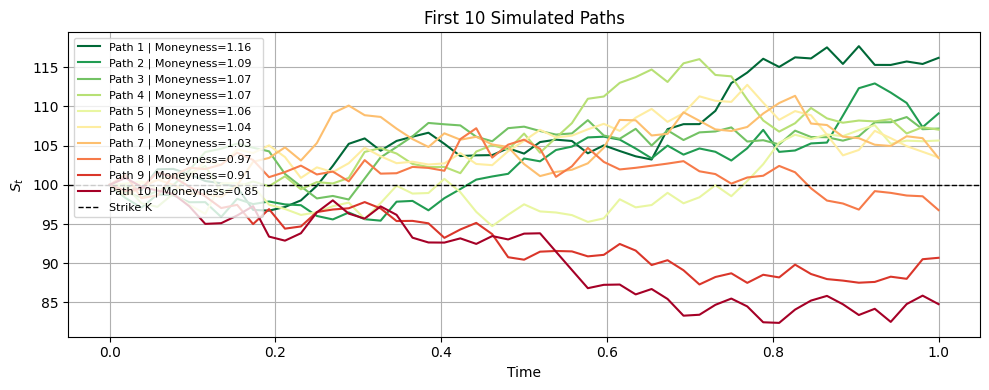

In [146]:
plot_n_paths(S_test, n=10)

In [147]:
def plot_n_deltas(paths, deltas1, deltas2, n, m=0, 
                  name1='deltas1', name2='deltas2'):
    """
    1.Plot the first n paths deltas of the simulated stock prices
    2.Compare deltas
    """
    global K, T

    # --- Sort paths by terminal moneyness, then filter on deltas ---
    first_n = paths[m:n+m,:]
    sort_idx = np.argsort(first_n[:, -1])[::-1]
    first_n = first_n[sort_idx, :]
    terminal_moneyness = first_n[:, -1] / K
    deltas1_n = deltas1[sort_idx, :]
    deltas2_n = deltas2[sort_idx, :]
    
    time_axis = np.linspace(0, T, first_n.shape[1])

    ytick_labels = [f"{terminal_moneyness[i]:.3f}" for i in range(n)]

    # --- Heatmap: deltas1 and deltas2 --- 
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    im1 = axes[0].imshow(deltas1_n, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    axes[0].set_title(name1)
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Terminal Moneyness $S_T/K$')
    axes[0].set_yticks(range(n))
    axes[0].set_yticklabels(ytick_labels)
    plt.colorbar(im1, ax=axes[0], label='Delta')

    im2 = axes[1].imshow(deltas2_n, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    axes[1].set_title(name2)
    axes[1].set_xlabel('Time Step')
    axes[1].set_ylabel('Terminal Moneyness $S_T/K$')
    axes[1].set_yticks(range(n))
    axes[1].set_yticklabels(ytick_labels)
    plt.colorbar(im2, ax=axes[1], label='Delta')

    plt.suptitle(f'Delta Heatmaps - {n} Paths sorted by Terminal Moneyness', fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- Plot Deltas difference --- 

    # Green: deltas1 > deltas2 | Red: deltas1 < deltas2
    deltas_diff = deltas1_n - deltas2_n
    fig, ax = plt.subplots(figsize=(16, 5))
    im3 = ax.imshow(deltas_diff, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1, origin='upper')
    ax.set_title(f'{name1} - {name2}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Terminal Moneyness $S_T/K$')
    ax.set_yticks(range(n))
    ax.set_yticklabels(ytick_labels)
    plt.colorbar(im3, ax=ax, label='Delta Difference (green: deltas1 > deltas2 | red: deltas1 < deltas2)')
    plt.suptitle(f'Delta Difference — {n} Paths sorted by Terminal Moneyness (ITM → OTM)', fontsize=13)
    plt.tight_layout()
    plt.show()


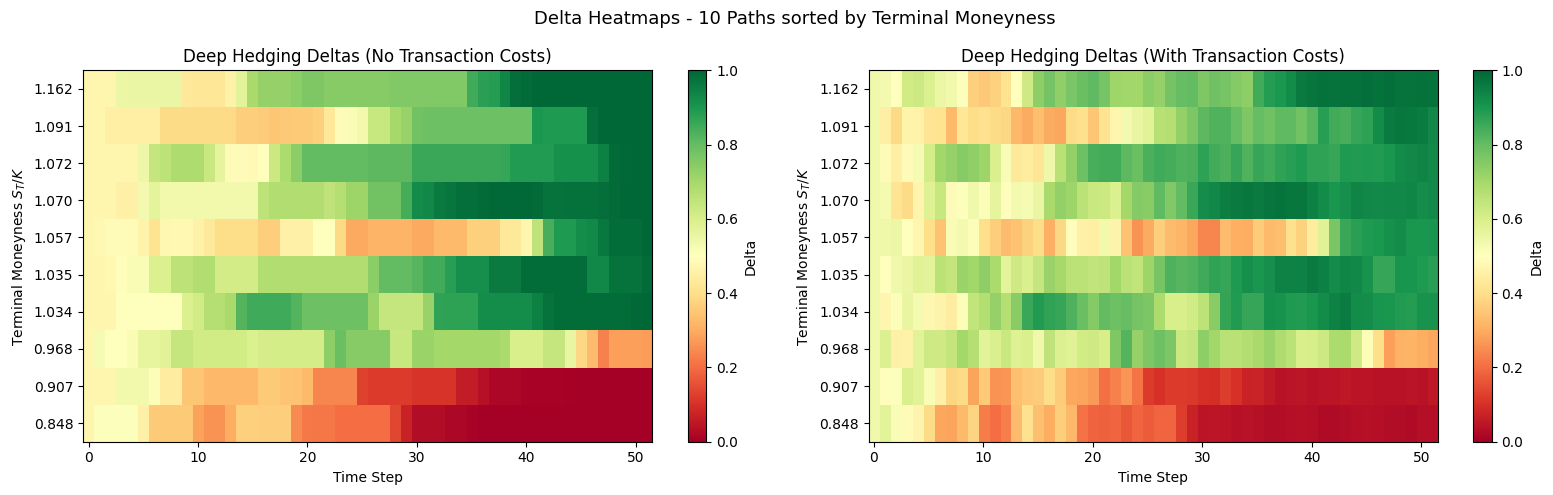

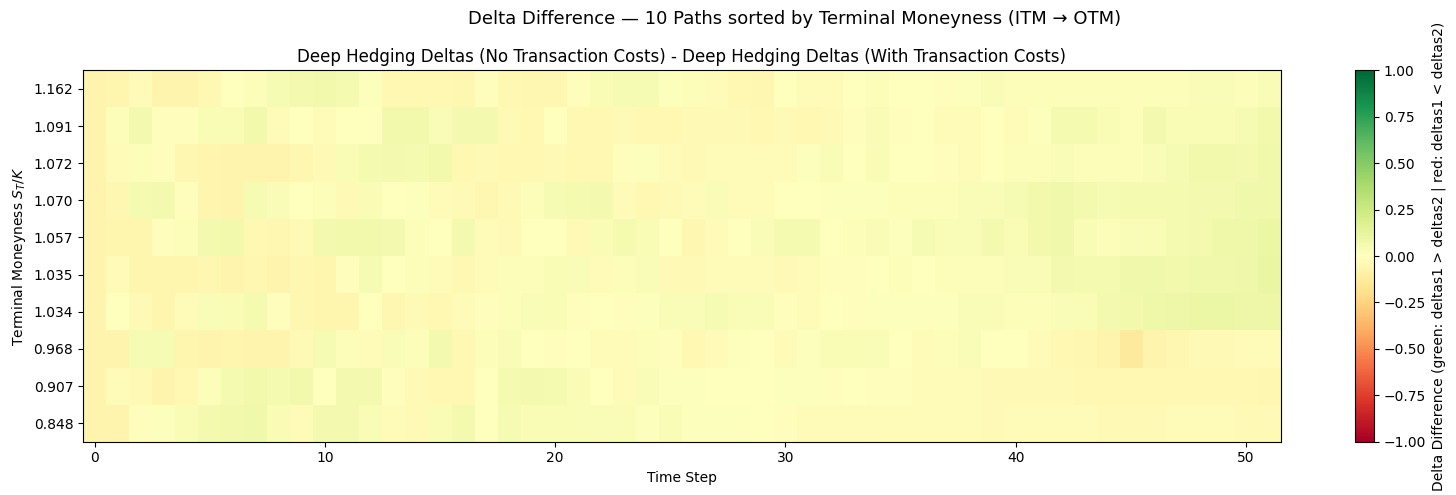

In [153]:
plot_n_deltas(S_test, bs_deltas_tc, model_deltas_tc.numpy(), n=10, m=0,
              name1='Deep Hedging Deltas (No Transaction Costs)',
              name2='Deep Hedging Deltas (With Transaction Costs)')

In [150]:
def plot_pnl_histogram(pnl1, pnl2, label1='P&L 1', label2='P&L 2', title='P&L Distribution', bins=50):
    plt.figure(figsize=(8,4))
    plt.hist(pnl1, bins=bins, density=True, alpha=0.5, label=label1)
    plt.hist(pnl2, bins=bins, density=True, alpha=0.5, label=label2)
    plt.title(title)
    plt.xlabel('P&L')
    plt.ylabel('Density')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


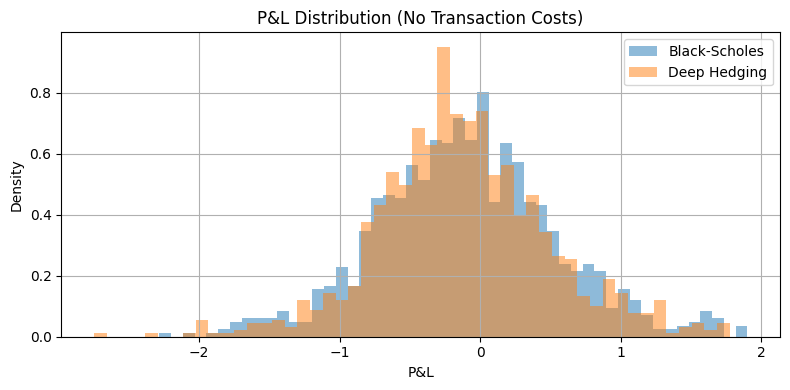

In [154]:
plot_pnl_histogram(bs_pnl_tc, model_pnl_tc.numpy(), label1='Black-Scholes', label2='Deep Hedging', title='P&L Distribution (No Transaction Costs)')

In [161]:
def plot_correlation(delta1, delta2, label1='delta1', label2='delta2'):
    delta1_c = delta1 - delta1.mean(axis=0)
    delta2_c = delta2 - delta2.mean(axis=0)
    num = (delta1_c * delta2_c).sum(axis=0)
    denum = np.sqrt((delta1_c**2).sum(axis=0) * (delta2_c**2).sum(axis=0))
    corr = num / denum

    global T
    time_axis = np.linspace(0, T, len(corr))

    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, corr, color='steelblue', linewidth=1.5)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.axhline(1, color='gray', linewidth=0.8, linestyle=':')
    plt.axhline(-1, color='gray', linewidth=0.8, linestyle=':')
    plt.fill_between(time_axis, corr, 0, alpha=0.15, color='steelblue')
    plt.ylim(-1.05, 1.05)
    plt.xlabel('Time')
    plt.ylabel('Correlation')
    plt.title(f'Delta Correlation: {label1} vs {label2}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

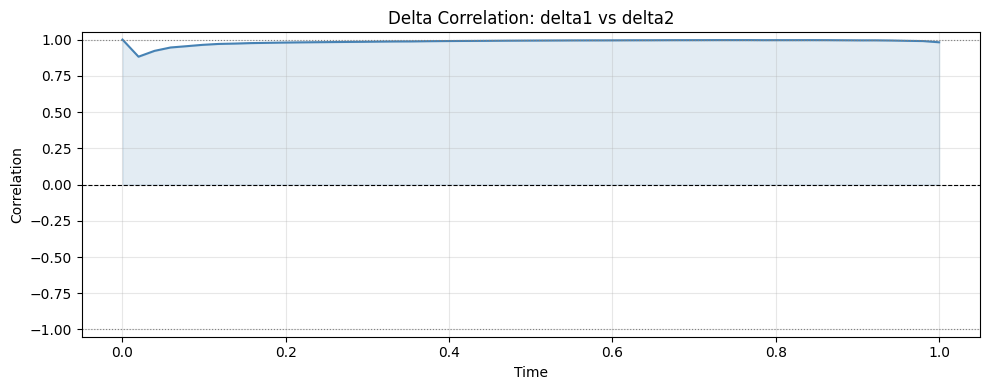

In [162]:
plot_correlation(bs_deltas_tc, model_deltas_tc.numpy())